# LSTM Model — Long Short-Term Memory
**Owner:** Pair 1  
**Environment:** Google Colab (GPU recommended for training)  
**Depends on:** `data/processed/` — run `00_data_pipeline.ipynb` first  
**Outputs:**
- `models/lstm/lstm_model.keras`
- `models/lstm/lstm_history.json`
- `models/lstm/lstm_metrics.json`

---
### Setup on Google Colab
1. Upload the entire `FraudGuard/` folder to Google Drive  
2. Open this notebook in Colab → Runtime → Change runtime type → **GPU**  
3. Run the environment cell below to mount Drive

In [1]:
## ── 0. Environment & paths ───────────────────────────────────────────────
import os, sys

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE       = '/content/drive/MyDrive/FraudGuard_Parent'
    # Install any missing packages
    os.system('pip install tensorflow scikit-learn matplotlib -q')
else:
    BASE = os.path.abspath(os.path.join(os.path.dirname(os.path.abspath('__file__')), '..'))

DATA_PROC  = os.path.join(BASE, 'data',   'processed')
MODEL_DIR  = os.path.join(BASE, 'models', 'lstm')
os.makedirs(MODEL_DIR, exist_ok=True)

print("BASE      :", BASE)
print("Data      :", DATA_PROC)
print("Model dir :", MODEL_DIR)

import tensorflow as tf
print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus if gpus else "None (running on CPU)")

Mounted at /content/drive
BASE      : /content/drive/MyDrive/FraudGuard_Parent
Data      : /content/drive/MyDrive/FraudGuard_Parent/data/processed
Model dir : /content/drive/MyDrive/FraudGuard_Parent/models/lstm
TF version: 2.20.0
GPUs available: None (running on CPU)


In [2]:
## ── 1. Load shared processed data ────────────────────────────────────────
import numpy as np, json

X_train = np.load(os.path.join(DATA_PROC, 'X_train.npy'))
X_val   = np.load(os.path.join(DATA_PROC, 'X_val.npy'))
X_test  = np.load(os.path.join(DATA_PROC, 'X_test.npy'))
y_train = np.load(os.path.join(DATA_PROC, 'y_train.npy'))
y_val   = np.load(os.path.join(DATA_PROC, 'y_val.npy'))
y_test  = np.load(os.path.join(DATA_PROC, 'y_test.npy'))

with open(os.path.join(DATA_PROC, 'class_weights.json')) as f:
    class_weights = json.load(f)
    # Convert string keys back to int
    class_weights = {int(k): v for k, v in class_weights.items()}

with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)

SEQ_LEN  = meta['seq_len']
N_FEATS  = meta['n_features']
FEATURES = meta['features']

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Class weights: {class_weights}")

X_train : (348676, 5, 15)
X_val   : (74716, 5, 15)
X_test  : (74717, 5, 15)
Class weights: {0: 0.5189063374328813, 1: 13.723079345088161}


## 2 · Build the LSTM Model
Implement a two-layer stacked LSTM with dropout and batch normalisation.  
Both members of the pair should review and agree on the final architecture before training.

In [3]:
## ── 2.1 Architecture ─────────────────────────────────────────────────────
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Masking
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC

model = Sequential([
    Masking(mask_value=0., input_shape=(SEQ_LEN, N_FEATS)),  # ignores padded steps
    LSTM(64, return_sequences=True, name='lstm_1'),
    BatchNormalization(),
    Dropout(0.3),
    LSTM(32, return_sequences=False, name='lstm_2'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid', name='output'),
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[AUC(name='auc'), 'accuracy'],
)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 5, 15)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 64)          │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,313 (130.13 KB)

 Trainable params: 33,121 (129.38 KB)

 Non-trainable params: 192 (768.00 B)

### Hyperparameter Options (Pair 1 — experiment and compare)
| Parameter | Default | Try also |
|-----------|---------|----------|
| LSTM units (layer 1) | 64 | 32, 128 |
| LSTM units (layer 2) | 32 | 16, 64  |
| Dropout rate | 0.3 | 0.2, 0.4 |
| Learning rate | 0.001 | 0.0005, 0.002 |
| Batch size | 256 | 128, 512 |

Document which configuration gave the best `val_auc` in your metrics JSON.

In [4]:
## ── 3. Training callbacks ─────────────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

MODEL_SAVE_PATH = os.path.join(MODEL_DIR, 'lstm_model.keras')

callbacks = [
    EarlyStopping(monitor='val_auc', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1),
    ModelCheckpoint(MODEL_SAVE_PATH, monitor='val_auc', save_best_only=True, mode='max', verbose=1),
]
print("Callbacks configured. Best model will be saved automatically.")

Callbacks configured. Best model will be saved automatically.


In [5]:
## ── 4. Train the model ────────────────────────────────────────────────────
import time

EPOCHS     = 50
BATCH_SIZE = 256

t0 = time.time()
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)
train_time_min = round((time.time() - t0) / 60, 1)
print(f"\nTraining complete in {train_time_min} minutes.")
print(f"Best val AUC: {max(history.history['val_auc']):.4f}")

# Save history
import json
hist_dict = {k: [float(v) for v in vals] for k, vals in history.history.items()}
hist_dict['train_time_min'] = train_time_min
with open(os.path.join(MODEL_DIR, 'lstm_history.json'), 'w') as f:
    json.dump(hist_dict, f, indent=2)
print("History saved:", os.path.join(MODEL_DIR, 'lstm_history.json'))

Epoch 1/50
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6363 - auc: 0.6729 - loss: 0.6886
Epoch 1: val_auc improved from None to 0.74505, saving model to /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_model.keras
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 69s 37ms/step - accuracy: 0.6735 - auc: 0.7015 - loss: 0.6418 - val_accuracy: 0.6812 - val_auc: 0.7451 - val_loss: 0.6402 - learning_rate: 0.0010
Epoch 2/50
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.7084 - auc: 0.7394 - loss: 0.6034
Epoch 2: val_auc improved from 0.74505 to 0.75831, saving model to /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_model.keras
1363/1363 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - accuracy: 0.7181 - auc: 0.7448 - loss: 0.5970 - val_accuracy: 0.5718 - val_auc: 0.7583 - 

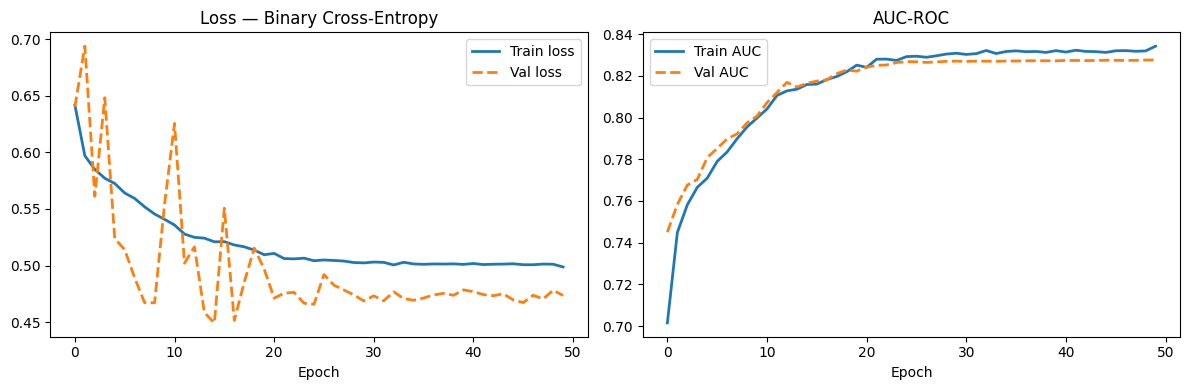

In [6]:
## ── 5. Plot training curves ───────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val loss',   linewidth=2, linestyle='--')
axes[0].set_title('Loss — Binary Cross-Entropy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC', linewidth=2)
axes[1].plot(history.history['val_auc'], label='Val AUC',   linewidth=2, linestyle='--')
axes[1].set_title('AUC-ROC')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, 'lstm_training_curves.png'), dpi=100, bbox_inches='tight')
plt.show()

In [7]:
## ── 6. Evaluate on test set ──────────────────────────────────────────────
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
import json

# Load best saved model (in case training restored weights)
model = tf.keras.models.load_model(MODEL_SAVE_PATH)

y_prob = model.predict(X_test, batch_size=256).flatten()
THRESHOLD = 0.45   # tuned for F1 — adjust if needed
y_pred = (y_prob >= THRESHOLD).astype(int)

auc  = roc_auc_score(y_test, y_prob)
f1   = f1_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print(f"=== LSTM Test Results ===")
print(f"AUC-ROC   : {auc:.4f}")
print(f"F1 (fraud): {f1:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"Threshold : {THRESHOLD}")
print()
print("Confusion Matrix:")
print(cm)
print()
print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraud']))

# Save metrics JSON — consumed by notebook 04 (evaluation solo)
with open(os.path.join(DATA_PROC, 'meta.json')) as f:
    meta = json.load(f)

metrics = {
    'model': 'lstm',
    'auc_roc': round(auc, 4),
    'f1': round(f1, 4),
    'precision': round(prec, 4),
    'recall': round(rec, 4),
    'threshold': THRESHOLD,
    'confusion_matrix': cm.tolist(),
    'train_time_min': json.load(open(os.path.join(MODEL_DIR, 'lstm_history.json')))['train_time_min'],
    'n_params': int(model.count_params()),
}
with open(os.path.join(MODEL_DIR, 'lstm_metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print("\nMetrics saved to:", os.path.join(MODEL_DIR, 'lstm_metrics.json'))
print("Share the entire models/lstm/ folder with the Evaluation Solo member.")

292/292 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
=== LSTM Test Results ===
AUC-ROC   : 0.8305
F1 (fraud): 0.1774
Precision : 0.1005
Recall    : 0.7550
Threshold : 0.45

Confusion Matrix:
[[53609 18386]
 [  667  2055]]

              precision    recall  f1-score   support

  Legitimate       0.99      0.74      0.85     71995
       Fraud       0.10      0.75      0.18      2722

    accuracy                           0.74     74717
   macro avg       0.54      0.75      0.51     74717
weighted avg       0.96      0.74      0.82     74717


Metrics saved to: /content/drive/MyDrive/FraudGuard_Parent/models/lstm/lstm_metrics.json
Share the entire models/lstm/ folder with the Evaluation Solo member.


## 7 · Pair 1 Contribution Notes
> **Both members must fill this section before submission.**

- Member A contributed: *(describe)*  
- Member B contributed: *(describe)*  
- Key design decisions made: *(list)*  
- Challenges encountered: *(list)*  
- Suggestions for improvement: *(list)*